In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.animation import FuncAnimation
from IPython.display import display, clear_output
import time
from collections import deque
import heapq

In [2]:
def parse_state(s):
    return [x for x in s.split('|') if x]

def canonical(stacks):
    return tuple(sorted(stacks))

In [3]:
def get_next_states(state_str):
    stacks = parse_state(state_str)
    next_states = {}
    for i, s in enumerate(stacks):
        if not s:
            continue
        top = s[-1]
        below = s[:-1]
        
        # move to table
        new_stacks = [stacks[j] for j in range(len(stacks)) if j != i and stacks[j]]
        if below:
            new_stacks.append(below)
        new_stacks.append(top)
        ns = canonical(new_stacks)
        if ns != canonical(stacks):
            next_states[ns] = f"{top} → table"

        # move onto another stack
        for j, t in enumerate(stacks):
            if i == j or not t:
                continue
            new_stacks = [stacks[k] for k in range(len(stacks)) if k not in (i, j) and stacks[k]]
            new_stacks.append(t + top)
            if below:
                new_stacks.append(below)
            ns = canonical(new_stacks)
            if ns != canonical(stacks):
                next_states[ns] = f"{top} → onto {t[-1]}"
    return [(state, desc) for state, desc in next_states.items()]

In [4]:
def heuristic(state, goal):
    g_stacks = parse_state(goal)
    # Build mapping: block -> (stack_index, position)
    goal_pos = {}
    for si, st in enumerate(g_stacks):
        for pi, b in enumerate(st):
            goal_pos[b] = (si, pi)
    h = 0
    state_stacks = parse_state(state)
    for st in state_stacks:
        for pi, b in enumerate(st):
            if b not in goal_pos:
                h += 1
                continue
            g_si, g_pi = goal_pos[b]
            # check if below blocks match goal stack
            if g_si < len(g_stacks) and pi <= g_pi:
                # verify all below blocks match
                ok = True
                for k in range(pi):
                    if k >= len(g_stacks[g_si]) or st[k] != g_stacks[g_si][k]:
                        ok = False
                        break
                if ok:
                    continue
            h += 1
    return h

In [5]:
def bfs(start, goal):
    start_c = canonical(parse_state(start))
    goal_c = canonical(parse_state(goal))
    if start_c == goal_c:
        return {'states': [start], 'moves': [], 'nodes': 1}
    parent = {start_c: None}
    move_desc = {}
    queue = deque([start_c])
    visited = set([start_c])
    nodes = 0
    while queue:
        cur = queue.popleft()
        nodes += 1
        cur_str = '|'.join(cur)
        for ns, desc in get_next_states(cur_str):
            if ns in visited:
                continue
            visited.add(ns)
            parent[ns] = cur
            move_desc[ns] = desc
            if ns == goal_c:
                # reconstruct path
                path = []
                moves = []
                state = ns
                while state:
                    path.append('|'.join(state))
                    state = parent[state]
                path.reverse()
                for i in range(1, len(path)):
                    moves.append(move_desc[canonical(parse_state(path[i]))])
                return {'states': path, 'moves': moves, 'nodes': nodes}
            queue.append(ns)
    return None  # no solution

In [6]:
def dfs(start, goal, depth_limit=55):
    start_c = canonical(parse_state(start))
    goal_c = canonical(parse_state(goal))
    if start_c == goal_c:
        return {'states': [start], 'moves': [], 'nodes': 1}
    parent = {start_c: None}
    move_desc = {}
    depth = {start_c: 0}
    stack = [start_c]
    visited = set([start_c])
    nodes = 0
    while stack:
        cur = stack.pop()
        nodes += 1
        cur_str = '|'.join(cur)
        if cur == goal_c:
            # reconstruct
            path = []
            moves = []
            state = cur
            while state:
                path.append('|'.join(state))
                state = parent[state]
            path.reverse()
            for i in range(1, len(path)):
                moves.append(move_desc[canonical(parse_state(path[i]))])
            return {'states': path, 'moves': moves, 'nodes': nodes}
        d = depth[cur]
        if d >= depth_limit:
            continue
        for ns, desc in get_next_states(cur_str):
            if ns not in visited:
                visited.add(ns)
                parent[ns] = cur
                move_desc[ns] = desc
                depth[ns] = d + 1
                stack.append(ns)
    return None

In [7]:
def greedy(start, goal):
    start_c = canonical(parse_state(start))
    goal_c = canonical(parse_state(goal))
    if start_c == goal_c:
        return {'states': [start], 'moves': [], 'nodes': 1, 'h0': heuristic(start, goal)}
    parent = {start_c: None}
    move_desc = {}
    closed = set()
    h0 = heuristic(start, goal)
    heap = [(h0, start_c)]          # (f = h, state)
    nodes = 0
    while heap:
        f, cur = heapq.heappop(heap)
        if cur in closed:
            continue
        closed.add(cur)
        nodes += 1
        cur_str = '|'.join(cur)
        if cur == goal_c:
            path = []
            moves = []
            state = cur
            while state:
                path.append('|'.join(state))
                state = parent[state]
            path.reverse()
            for i in range(1, len(path)):
                moves.append(move_desc[canonical(parse_state(path[i]))])
            return {'states': path, 'moves': moves, 'nodes': nodes, 'h0': h0}
        for ns, desc in get_next_states(cur_str):
            if ns in closed:
                continue
            if ns not in parent:
                parent[ns] = cur
                move_desc[ns] = desc
            heapq.heappush(heap, (heuristic('|'.join(ns), goal), ns))
    return None

In [8]:
def astar(start, goal):
    start_c = canonical(parse_state(start))
    goal_c = canonical(parse_state(goal))
    if start_c == goal_c:
        return {'states': [start], 'moves': [], 'nodes': 1, 'h0': heuristic(start, goal)}
    parent = {start_c: None}
    move_desc = {}
    g_score = {start_c: 0}
    closed = set()
    h0 = heuristic(start, goal)
    heap = [(h0, 0, start_c)]          # (f, g, state) - g for tie‑breaking
    nodes = 0
    while heap:
        f, g, cur = heapq.heappop(heap)
        if cur in closed:
            continue
        closed.add(cur)
        nodes += 1
        cur_str = '|'.join(cur)
        if cur == goal_c:
            path = []
            moves = []
            state = cur
            while state:
                path.append('|'.join(state))
                state = parent[state]
            path.reverse()
            for i in range(1, len(path)):
                moves.append(move_desc[canonical(parse_state(path[i]))])
            return {'states': path, 'moves': moves, 'nodes': nodes, 'h0': h0}
        for ns, desc in get_next_states(cur_str):
            if ns in closed:
                continue
            tentative_g = g + 1
            if tentative_g < g_score.get(ns, float('inf')):
                g_score[ns] = tentative_g
                parent[ns] = cur
                move_desc[ns] = desc
                f_new = tentative_g + heuristic('|'.join(ns), goal)
                heapq.heappush(heap, (f_new, tentative_g, ns))
    return None

In [9]:
levels = [
    {"name": "Easy", "start": "ABC", "goal": "A|BC"},
    {"name": "Medium", "start": "ABCD", "goal": "AB|CD"},
    {"name": "Hard", "start": "ABCDE", "goal": "AB|CDE"},
    {"name": "Very Hard", "start": "ABCDEF", "goal": "BCD|AEF"},
    {"name": "Expert", "start": "ABCDEFG", "goal": "ABC|DEFG"},
]

In [10]:
results = []
for lvl in levels:
    print(f"\n--- {lvl['name']} ---")
    start, goal = lvl['start'], lvl['goal']
    bfs_res = bfs(start, goal)
    dfs_res = dfs(start, goal)
    greedy_res = greedy(start, goal)
    astar_res = astar(start, goal)
    results.append({
        'level': lvl['name'],
        'BFS': bfs_res,
        'DFS': dfs_res,
        'Greedy': greedy_res,
        'A*': astar_res
    })
    # Print summary
    print(f"BFS    : {bfs_res['moves']} moves, {bfs_res['nodes']} nodes")
    print(f"DFS    : {dfs_res['moves']} moves, {dfs_res['nodes']} nodes")
    print(f"Greedy : {greedy_res['moves']} moves, {greedy_res['nodes']} nodes")
    print(f"A*     : {astar_res['moves']} moves, {astar_res['nodes']} nodes")


--- Easy ---
BFS    : ['C → table', 'B → table', 'C → onto B'] moves, 3 nodes
DFS    : ['C → table', 'B → table', 'C → onto B'] moves, 6 nodes
Greedy : ['C → table', 'B → table', 'C → onto B'] moves, 4 nodes
A*     : ['C → table', 'B → table', 'C → onto B'] moves, 5 nodes

--- Medium ---
BFS    : ['D → table', 'C → table', 'D → onto C'] moves, 3 nodes
DFS    : ['D → table', 'C → onto D', 'B → table', 'C → onto B', 'D → onto A', 'C → table', 'D → onto C', 'B → onto A'] moves, 56 nodes
Greedy : ['D → table', 'C → table', 'D → onto C'] moves, 6 nodes
A*     : ['D → table', 'C → table', 'D → onto C'] moves, 6 nodes

--- Hard ---
BFS    : ['E → table', 'D → table', 'C → table', 'D → onto C', 'E → onto D'] moves, 17 nodes
DFS    : ['E → table', 'D → onto E', 'C → onto D', 'B → table', 'C → onto B', 'D → onto C', 'E → onto A', 'D → onto E', 'C → table', 'B → onto C', 'D → onto B', 'E → table', 'D → onto E', 'B → onto D', 'C → onto A', 'B → onto C', 'D → table', 'E → onto D', 'B → onto E', 'C

In [14]:
import pandas as pd

data = []
for res in results:
    for algo in ['BFS','DFS','Greedy','A*']:
        d = res[algo]
        data.append({
            'Level': res['level'],
            'Algorithm': algo,
            'Path length': len(d['moves']),
            'Nodes expanded': d['nodes']
        })
df = pd.DataFrame(data)
print(df)

        Level Algorithm  Path length  Nodes expanded
0        Easy       BFS            3               3
1        Easy       DFS            3               6
2        Easy    Greedy            3               4
3        Easy        A*            3               5
4      Medium       BFS            3               3
5      Medium       DFS            8              56
6      Medium    Greedy            3               6
7      Medium        A*            3               6
8        Hard       BFS            5              17
9        Hard       DFS           39             345
10       Hard    Greedy            7              10
11       Hard        A*            5              26
12  Very Hard       BFS            9            1757
13  Very Hard       DFS           36              55
14  Very Hard    Greedy            9              16
15  Very Hard        A*            9             748
16     Expert       BFS            7             227
17     Expert       DFS           55          

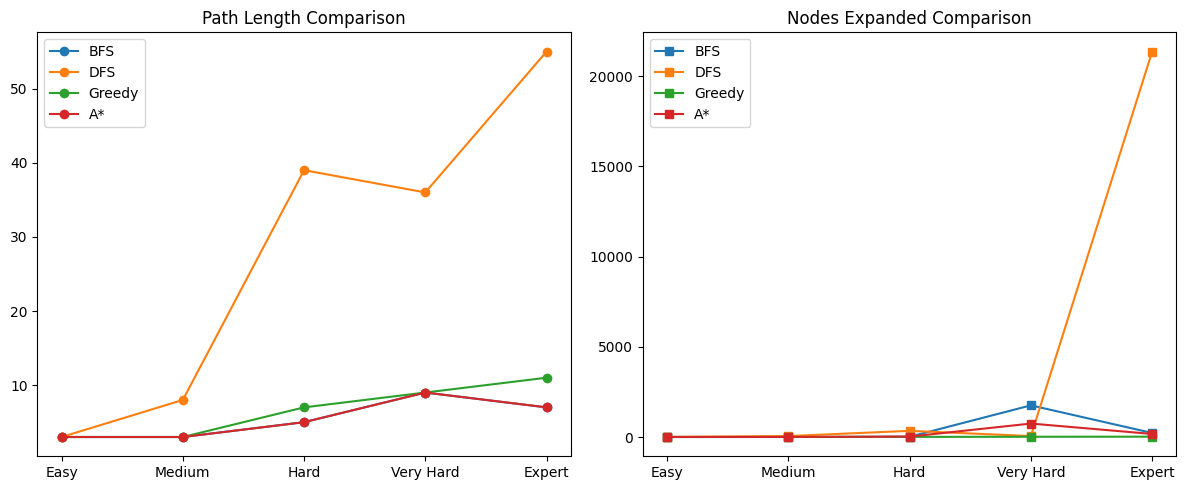

In [12]:
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(12,5))
for algo in ['BFS','DFS','Greedy','A*']:
    subset = df[df.Algorithm == algo]
    ax1.plot(subset.Level, subset['Path length'], marker='o', label=algo)
    ax2.plot(subset.Level, subset['Nodes expanded'], marker='s', label=algo)
ax1.set_title('Path Length Comparison')
ax1.legend()
ax2.set_title('Nodes Expanded Comparison')
ax2.legend()
plt.tight_layout()
plt.show()